In [1]:
print('hello')

hello


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [7]:
df = pd.read_csv('insurance.csv')
print('Dataset Loaded Successfully:')
print(df.head())

Dataset Loaded Successfully:
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86


In [8]:
dataset = pd.get_dummies(df)

print(dataset.head())
print(dataset.columns)

   age   bmi  children  expenses  sex_female  sex_male  smoker_no  smoker_yes  \
0   19  27.9         0  16884.92        True     False      False        True   
1   18  33.8         1   1725.55       False      True       True       False   
2   28  33.0         3   4449.46       False      True       True       False   
3   33  22.7         0  21984.47       False      True       True       False   
4   32  28.9         0   3866.86       False      True       True       False   

   region_northeast  region_northwest  region_southeast  region_southwest  
0             False             False             False              True  
1             False             False              True             False  
2             False             False              True             False  
3             False              True             False             False  
4             False              True             False             False  
Index(['age', 'bmi', 'children', 'expenses', 'sex_female'

In [9]:
dataset = dataset.sample(frac=1, random_state=1337)

train_dataset = dataset.sample(frac=0.8, random_state=1337)
test_dataset = dataset.drop(train_dataset.index)

print("Training data:", train_dataset.shape)
print("Testing data:", test_dataset.shape)

Training data: (1070, 12)
Testing data: (268, 12)


In [10]:
train_labels = train_dataset.pop("expenses")
test_labels = test_dataset.pop("expenses")

print("Train features:", train_dataset.shape)
print("Train labels:", train_labels.shape)
print("Test features:", test_dataset.shape)
print("Test labels:", test_labels.shape)

Train features: (1070, 11)
Train labels: (1070,)
Test features: (268, 11)
Test labels: (268,)


In [11]:
normalizer = layers.Normalization(axis=-1)

normalizer.adapt(np.array(train_dataset))

print("Normalizer ready!")

Normalizer ready!


In [25]:
def build_model():
    model = keras.Sequential([
        normalizer,
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])

    model.compile(
        loss='mean_absolute_error',
        optimizer=tf.keras.optimizers.Adam(0.001),
        metrics=[
            tf.keras.metrics.MeanSquaredError()
        ]
    )

    return model

model = build_model()

print("Model recreated successfully!")

Model recreated successfully!


In [26]:
history = model.fit(
    train_dataset,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

print("Training completed!")

Training completed!


In [15]:
mae = model.evaluate(
    test_dataset,
    test_labels,
    verbose=0
)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 3141.519775390625


In [16]:
test_predictions = model.predict(test_dataset).flatten()

print("Predictions created successfully!")
print(test_predictions[:5])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Predictions created successfully!
[ 2741.2366 32985.414   4390.2812 38488.4    13238.701 ]


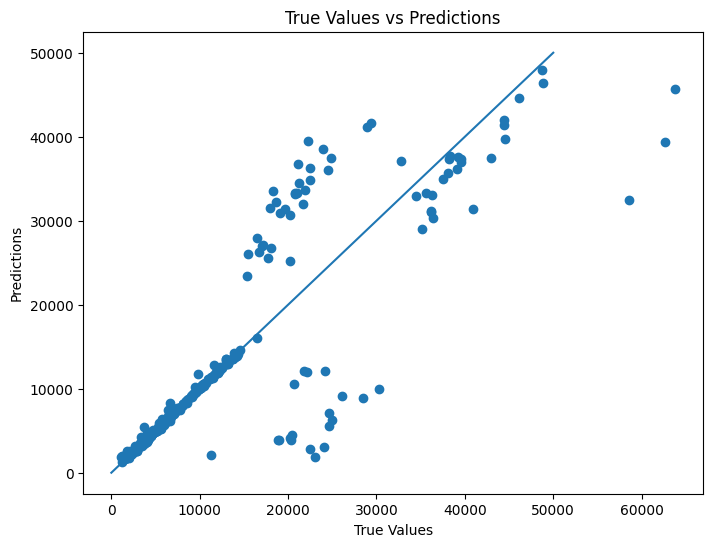

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    test_labels,
    test_predictions
)

plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")

plt.plot(
    [0, 50000],
    [0, 50000]
)

plt.show()

9/9 - 0s - 6ms/step - loss: 3108.0933 - mean_squared_error: 42195284.0000
Testing set Mean Abs Error: 3108.09 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


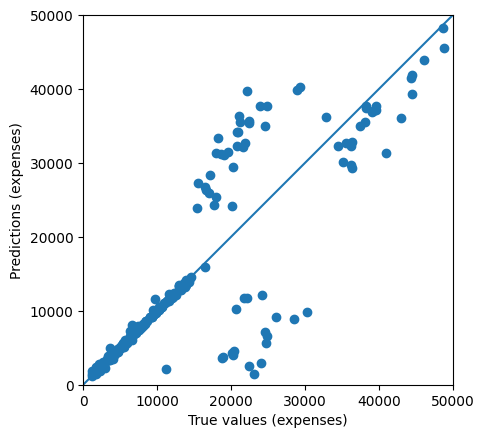

In [27]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
